In [1]:
# Necessary libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
from sklearn.metrics import silhouette_score
df = pd.read_csv("cleaned_tickets.csv")
print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [2]:
# Vectorise cleaned text
vectorizer = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.5, ngram_range=(1,2))
x = vectorizer.fit_transform(df["Processed Description"])
print(x.shape)

(8469, 1000)


### Text Vectorisation
The clean data was converted into numerical format using IF-IDF vectorisation. This allows for processing the text data by representing each document as a vector of features

In [3]:
#K-Means 
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(x) 
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Processed Description,cluster
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,billing zip code appreciate requested website ...,1
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,change existing intermittent,3
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,turning yesterday respond really charger came ...,3
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,youre interested id love see happen check feed...,3
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,note seller responsible damages arising delive...,3


### K-Means clustering
KMean clustering was applied to group similar customer support tickets based on their textual content. This help identify underlying patterns and categories of customer issues.

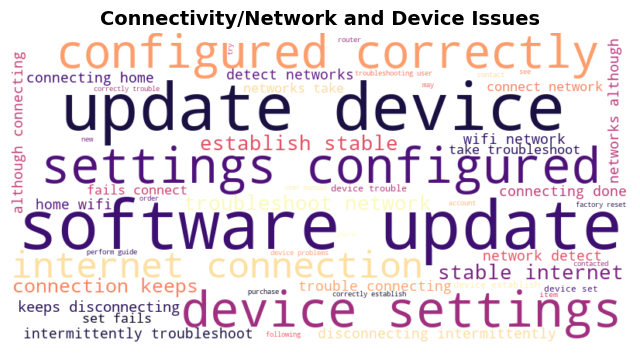

Cluster 0 - Top 10 words:
device:666
update:456
software:454
network:433
troubleshoot:376
connecting:362
networks:343
settings:231
configured:205
correctly:205



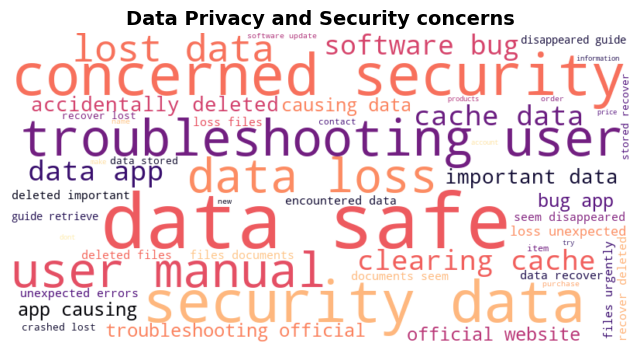

Cluster 1 - Top 10 words:
data:1517
troubleshooting:564
app:443
user:405
safe:396
concerned:393
security:393
manual:389
files:359
loss:358



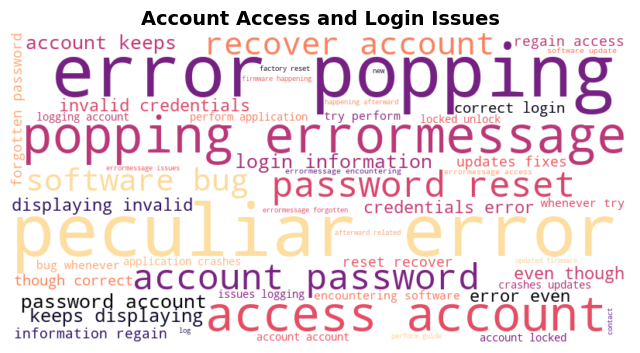

Cluster 2 - Top 10 words:
account:1251
error:622
password:458
peculiar:412
popping:412
errormessage:412
access:388
software:291
reset:274
updates:256



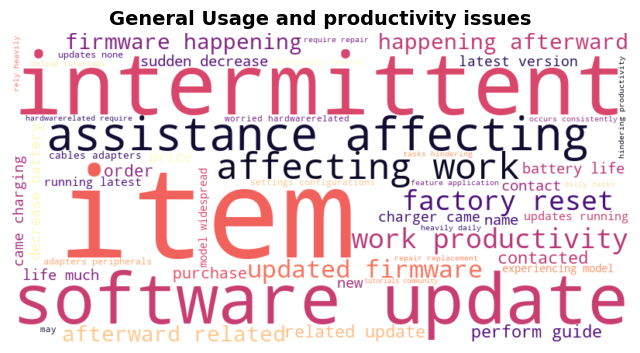

Cluster 3 - Top 10 words:
productivity:559
software:527
work:467
update:465
updated:408
updates:405
assistance:398
intermittent:394
reset:385
affecting:379



In [4]:
# Wordclouds for each cluster
topic_mapping = {
    0: "Connectivity/Network and Device Issues", 
    1: "Data Privacy and Security concerns", 
    2: "Account Access and Login Issues",
    3: "General Usage and productivity issues"
}
df['cluster_name'] = df['cluster'].map(topic_mapping)
n_clusters = len(df['cluster'].unique())
for i in range(n_clusters):
    cluster_text = " ".join(df[df['cluster'] == i]['Processed Description'])
    #Split into words and count frequencies
    words = re.findall(r'\b[a-zA-Z]{3,}\b', cluster_text.lower()) 
    word_count = Counter(words)
    
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma', max_words=50).generate(cluster_text)
    current_label = topic_mapping[i] 
    # Plot
    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"{current_label}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
        # Top 5 words
    top_words = word_count.most_common(10)
    print(f"Cluster {i} - Top 10 words:")
    for word, count in top_words:
        print(f"{word}:{count}")
    print()

Word clouds were generated for each cluster to visualise the most frequent terms, which will help in interpreting the underlying themes of each group.
## Cluster interpretation 
Some overlap is observed between clusters such as software and update as seen in clusters 0 and 3. This suggests that certain issues span multiple categories. 
### The connectivity/network & device setup issues
This cluster represents issues related to network connectivity and device configuration, where users appear to be experiencing network problems or difficulties setting up devices correctly. 
### Data security and loss concerns 
In the second cluster, most issues were security and data-related concerns raised by customers. 
### Account Access and Authentication Issues
for this cluster: top words where account, password reset, and access issues are mentioned, indicating that customers are having problems with authentication-related issues and application/device access. 
### General usage and productivity support
This cluster reflects general usage queries and productivity-related support, where some customers are requesting guidance on using applications/devices and improving workflows.

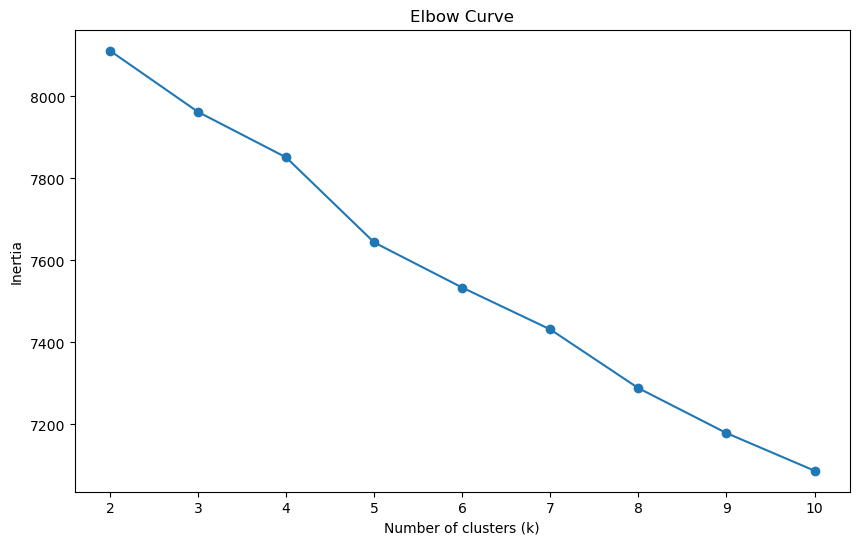

In [5]:
x = vectorizer.fit_transform(df["Processed Description"])
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)

    # store inertia
    inertia.append (kmeans.inertia_)
    #silhouette score
    score = silhouette_score(x, labels)
    silhouette_scores.append(score)
# plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()


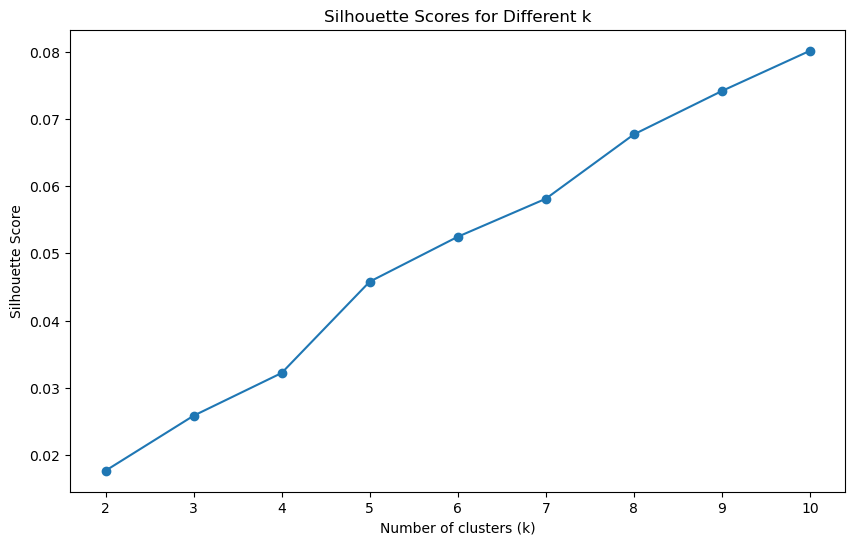

In [6]:
# plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k')
plt.show()

In [7]:
%pip install sentence-transformers
%pip install --upgrade datasets transformers sentence-transformers

   ---------------------------------------- 0.0/566.4 kB ? eta -:--:--
   ---------------------------------------- 566.4/566.4 kB 6.6 MB/s  0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached transformers-5.4.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.8.0-py3-none-any.whl.metadata (13 kB)
Using cached datasets-4.8.4-py3-none-any.whl (526 kB)
Using cached transformers-5.4.0-py3-none-any.whl (10.1 MB)
Using cached huggingface_hub-1.8.0-py3-none-any.whl (625 kB)

  Attempting uninstall: huggingface-hub

    Found existing installation: huggingface_hub 0.36.2

   ---------------------------------------- 0/3 [huggingface-hub]
    Uninstalling huggingface_hub-0.36.2:
   ---------------------------------------- 0/3 [huggingface-hub]
      Successfully uninstalled huggingface_hub-0.36.2
   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   ------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [15]:
from sentence_transformers import SentenceTransformer

# Load the model
model = 'all-MiniLM-L6-v2'
embedding_model = SentenceTransformer(model)
print(f"Loaded sentance-transformer model: '{model}'")

# Some example sentences for quality check

example_tickets = [
    "Password reset requested; I am locked out of my account.", # Account related
    "Login failed: system won't accept my sign-in details.",    # Account related
    "I've been double-billed for this month's plan.",           # Billing related
    "I need a PDF of my latest transaction receipt.",         #Billing related
    "Is it possible to include a CSV export option?"          # Requesting a new feature
]

# generate embeddings
example_embeddings = embedding_model.encode(example_tickets)
# check it works
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity([example_embeddings[0]], [example_embeddings[1]])
print(f"Test Similarity score for two accounts tickets: {sim[0][0]:.4f}")
sim = cosine_similarity([example_embeddings[0]], [example_embeddings[4]])
print(f"Test Similarity score for different tickets: {sim[0][0]:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded sentance-transformer model: 'all-MiniLM-L6-v2'
Test Similarity score for two accounts tickets: 0.5435
Test Similarity score for different tickets: -0.1041


In [17]:
# Process the dataset
df['embeddings'] = list(embedding_model.encode(df['Ticket Description'].astype(str), show_progress_bar=True))
# Save the dataframe
df.to_csv('embedded_customer_support_tickets.csv', index=False)

Batches:   0%|          | 0/265 [00:00<?, ?it/s]